In [4]:
# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Display all dataframe columns
pd.set_option("display.max_columns", None)

# Fix the random state so results remain reproducible
RANDOM_STATE = 42

In [5]:
# ============================================================
# 2. LOAD THE FINAL DATASET
# ============================================================
# Change the path according to the location of your CSV file.

DATA_PATH = Path("../data/processed/dataset_labelled_with_score.csv")

# Example path for the uploaded dataset:
# DATA_PATH = Path("/mnt/data/dataset_labelled_with_score(2).csv")

# Check whether the dataset exists
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}\n"
        "Please update DATA_PATH with the correct file location."
    )

# Read the CSV dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (4172, 61)


,place_id,latitude,longitude,search_area,primary_type,searched_as,label,feasibility_score,feasibility_label,cluster,bank_count_500m,bank_count_500m_normalized,bank_count_500m_contribution,bus_stop_count_500m,bus_stop_count_500m_normalized,bus_stop_count_500m_contribution,cinema_count_500m,cinema_count_500m_normalized,cinema_count_500m_contribution,clinic_count_500m,clinic_count_500m_normalized,clinic_count_500m_contribution,college_count_500m,college_count_500m_normalized,college_count_500m_contribution,hospital_count_500m,hospital_count_500m_normalized,hospital_count_500m_contribution,museum_count_500m,museum_count_500m_normalized,museum_count_500m_contribution,office_count_500m,office_count_500m_normalized,office_count_500m_contribution,parking_space_count_500m,parking_space_count_500m_normalized,parking_space_count_500m_contribution,recreation_count_500m,recreation_count_500m_normalized,recreation_count_500m_contribution,retail_count_500m,retail_count_500m_normalized,retail_count_500m_contribution,school_count_500m,school_count_500m_normalized,school_count_500m_contribution,temple_count_500m,temple_count_500m_normalized,temple_count_500m_contribution,nearest_restaurant_m,nearest_restaurant_m_normalized,nearest_restaurant_m_contribution,competitor_count_500m,competitor_count_500m_normalized,competitor_count_500m_contribution,avg_restaurant_rating_500m,avg_restaurant_rating_500m_normalized,avg_restaurant_rating_500m_contribution,avg_review_ratings_500m,avg_review_ratings_500m_normalized,avg_review_ratings_500m_contribution
0,ChIJsZ5mY70Z6zkRRBczgL9a8ms,27.699546,85.337687,Baneshwor,restaurant,restaurant,1,18.652333,Moderate,0,26,0.273684,0.018875,1,0.090909,0.007885,0,0.000000,0.000000,44,0.578947,0.026628,22,0.343750,0.023808,9,0.290323,0.012063,1,0.027778,0.00446,54,0.524272,0.022053,5,0.217391,0.016110,21,0.272727,0.009656,52,0.329114,0.007984,35,0.583333,0.017102,15,0.144231,0.010072,66.357920,0.015377,0.000851,20,0.837398,0.006476,4.265000,0.183750,0.002125,87.700000,0.941020,0.000377
1,ChIJ5SO0EQ0Z6zkRTMnqUebrTqA,27.692262,85.336472,Baneshwor,restaurant,restaurant,1,27.954012,High,2,43,0.452632,0.031216,4,0.363636,0.031538,1,0.142857,0.025274,46,0.605263,0.027838,37,0.578125,0.040041,13,0.419355,0.017424,1,0.027778,0.00446,66,0.640777,0.026953,6,0.260870,0.019332,16,0.207792,0.007357,80,0.506329,0.012284,40,0.666667,0.019545,13,0.125000,0.008729,3.883478,0.000900,0.000050,44,0.642276,0.004967,4.247727,0.188068,0.002175,159.477273,0.892192,0.000357
2,ChIJTdMmLgAZ6zkR84zXOWwdgPE,27.689064,85.334295,Baneshwor,restaurant,restaurant,1,37.665885,High,2,57,0.600000,0.041379,6,0.545455,0.047307,3,0.428571,0.075822,65,0.855263,0.039336,49,0.765625,0.053028,12,0.387097,0.016084,1,0.027778,0.00446,68,0.660194,0.027770,9,0.391304,0.028998,15,0.194805,0.006897,66,0.417722,0.010134,28,0.466667,0.013681,6,0.057692,0.004029,35.022157,0.008116,0.000449,48,0.609756,0.004716,4.231250,0.192187,0.002222,201.104167,0.863875,0.000346
3,ChIJ3Ru72S8Z6zkR6JYG3tsYlGk,27.681549,85.341340,Baneshwor,restaurant,restaurant,1,12.152369,Low,1,5,0.052632,0.003630,0,0.000000,0.000000,0,0.000000,0.000000,23,0.302632,0.013919,6,0.093750,0.006493,4,0.129032,0.005361,0,0.000000,0.00000,66,0.640777,0.026953,4,0.173913,0.012888,26,0.337662,0.011955,78,0.493671,0.011976,16,0.266667,0.007818,17,0.163462,0.011414,5.217717,0.001209,0.000067,14,0.886179,0.006854,4.371429,0.157143,0.001817,83.214286,0.944072,0.000378
4,ChIJJbL_SlQZ6zkRFWSjunPmuVU,27.688812,85.334080,Baneshwor,restaurant,restaurant,1,37.304810,High,2,55,0.578947,0.039927,6,0.545455,0.047307,3,0.428571,0.075822,66,0.868421,0.039942,46,0.718750,0.049781,11,0.354839,0.014744,1,0.027778,0.00446,65,0.631068,0.026545,10,0.434783,0.032220,15,0.194805,0.006897,64,0.405063,0.009827,27,0.450000,0.013193,7,0.067308,0.004700,35.022157,0.008116,0.000449,47,0.617886,0.004779,4.270213,0.182447,0.002110,200.893617,0.864018,0.000346


In [6]:
# ============================================================
# 3. DEFINE THE RAW MODEL FEATURES
# ============================================================
# These features describe the selected location within a
# 500-meter radius.
#
# Only features that can be collected for a new map location
# are included.
#
# EWM scores, normalized values, cluster labels and contribution
# columns are not included because they can cause data leakage.

NUMERIC_FEATURES = [
    "bank_count_500m",
    "bus_stop_count_500m",
    "cinema_count_500m",
    "clinic_count_500m",
    "college_count_500m",
    "hospital_count_500m",
    "museum_count_500m",
    "office_count_500m",
    "parking_space_count_500m",
    "recreation_count_500m",
    "retail_count_500m",
    "school_count_500m",
    "temple_count_500m",
    "nearest_restaurant_m",
    "competitor_count_500m",
    "avg_restaurant_rating_500m",
    "avg_review_ratings_500m",
]

# search_area is categorical because area names are text values
CATEGORICAL_FEATURES = [
    "search_area"
]

# Combine numerical and categorical feature names
MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Define the target column
TARGET_COLUMN = "feasibility_label"

print("Number of numerical features:", len(NUMERIC_FEATURES))
print("Number of categorical features:", len(CATEGORICAL_FEATURES))
print("Total selected features:", len(MODEL_FEATURES))

Number of numerical features: 17
Number of categorical features: 1
Total selected features: 18


In [7]:
# ============================================================
# 4. VALIDATE REQUIRED COLUMNS
# ============================================================
# This step checks whether all selected features and the target
# column are available in the dataset.

required_columns = MODEL_FEATURES + [TARGET_COLUMN]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "The following required columns are missing:\n"
        + "\n".join(f"- {column}" for column in missing_columns)
    )

print("All required feature and target columns are available.")

All required feature and target columns are available.


In [8]:
# ============================================================
# 5. SELECT THE RAW 500-METER FEATURES
# ============================================================
# X represents the input feature matrix.
#
# Only the selected raw location-based features are copied
# from the original dataset.

X = df[MODEL_FEATURES].copy()

print("Selected input features:")
print(X.columns.tolist())

print("\nFeature matrix shape:", X.shape)

X.head()

Selected input features:
['bank_count_500m', 'bus_stop_count_500m', 'cinema_count_500m', 'clinic_count_500m', 'college_count_500m', 'hospital_count_500m', 'museum_count_500m', 'office_count_500m', 'parking_space_count_500m', 'recreation_count_500m', 'retail_count_500m', 'school_count_500m', 'temple_count_500m', 'nearest_restaurant_m', 'competitor_count_500m', 'avg_restaurant_rating_500m', 'avg_review_ratings_500m', 'search_area']

Feature matrix shape: (4172, 18)


,bank_count_500m,bus_stop_count_500m,cinema_count_500m,clinic_count_500m,college_count_500m,hospital_count_500m,museum_count_500m,office_count_500m,parking_space_count_500m,recreation_count_500m,retail_count_500m,school_count_500m,temple_count_500m,nearest_restaurant_m,competitor_count_500m,avg_restaurant_rating_500m,avg_review_ratings_500m,search_area
0,26,1,0,44,22,9,1,54,5,21,52,35,15,66.357920,20,4.265000,87.700000,Baneshwor
1,43,4,1,46,37,13,1,66,6,16,80,40,13,3.883478,44,4.247727,159.477273,Baneshwor
2,57,6,3,65,49,12,1,68,9,15,66,28,6,35.022157,48,4.231250,201.104167,Baneshwor
3,5,0,0,23,6,4,0,66,4,26,78,16,17,5.217717,14,4.371429,83.214286,Baneshwor
4,55,6,3,66,46,11,1,65,10,15,64,27,7,35.022157,47,4.270213,200.893617,Baneshwor


In [9]:
# ============================================================
# 6. IDENTIFY EXCLUDED COLUMNS
# ============================================================
# These columns should not be used for model training.
#
# Reasons for exclusion:
# - feasibility_score was used to generate the target label
# - cluster is an output from clustering
# - normalized columns are already transformed versions
# - contribution columns are part of the EWM calculation
# - place_id and restaurant_name are identifiers
#
# Including these columns could cause data leakage.

excluded_columns = [
    column
    for column in df.columns
    if (
        column in {
            "feasibility_score",
            "cluster",
            "label",
            "place_id",
            "restaurant_name",
            "address",
        }
        or column.endswith("_normalized")
        or column.endswith("_contribution")
    )
]

print("Excluded columns:")
for column in excluded_columns:
    print(column)

Excluded columns:
place_id
label
feasibility_score
cluster
bank_count_500m_normalized
bank_count_500m_contribution
bus_stop_count_500m_normalized
bus_stop_count_500m_contribution
cinema_count_500m_normalized
cinema_count_500m_contribution
clinic_count_500m_normalized
clinic_count_500m_contribution
college_count_500m_normalized
college_count_500m_contribution
hospital_count_500m_normalized
hospital_count_500m_contribution
museum_count_500m_normalized
museum_count_500m_contribution
office_count_500m_normalized
office_count_500m_contribution
parking_space_count_500m_normalized
parking_space_count_500m_contribution
recreation_count_500m_normalized
recreation_count_500m_contribution
retail_count_500m_normalized
retail_count_500m_contribution
school_count_500m_normalized
school_count_500m_contribution
temple_count_500m_normalized
temple_count_500m_contribution
nearest_restaurant_m_normalized
nearest_restaurant_m_contribution
competitor_count_500m_normalized
competitor_count_500m_contribution

In [11]:
# ============================================================
# 7. VERIFY THAT LEAKAGE COLUMNS ARE NOT IN X
# ============================================================
# Assertions stop the notebook if a leakage column is
# accidentally included in the feature matrix.

assert "feasibility_score" not in X.columns
assert "cluster" not in X.columns
assert "label" not in X.columns
assert "place_id" not in X.columns

assert not any(
    column.endswith("_normalized")
    for column in X.columns
)

assert not any(
    column.endswith("_contribution")
    for column in X.columns
)

print("Data leakage checks passed.")

Data leakage checks passed.


In [12]:
# ============================================================
# 8. PREPARE THE TARGET COLUMN
# ============================================================
# The feasibility label is used as the prediction target.
#
# Text values are cleaned by:
# - converting to string
# - removing extra spaces
# - converting labels to title case

target_text = (
    df[TARGET_COLUMN]
    .astype("string")
    .str.strip()
    .str.title()
)

print("Unique feasibility labels:")
print(target_text.unique())

Unique feasibility labels:
<StringArray>
['Moderate', 'High', 'Low']
Length: 3, dtype: string


In [13]:
# ============================================================
# 9. VALIDATE THE FEASIBILITY LABELS
# ============================================================
# The dataset should contain only:
# Low, Moderate and High.

valid_labels = {
    "Low",
    "Moderate",
    "High"
}

actual_labels = set(
    target_text.dropna().unique()
)

invalid_labels = actual_labels - valid_labels

if invalid_labels:
    raise ValueError(
        f"Invalid feasibility labels found: {invalid_labels}"
    )

if target_text.isna().any():
    missing_target_count = target_text.isna().sum()

    raise ValueError(
        f"{missing_target_count} target values are missing."
    )

print("Feasibility labels are valid.")

Feasibility labels are valid.


In [14]:
# ============================================================
# 10. ENCODE THE TARGET LABELS
# ============================================================
# Machine learning models require numerical target values.
#
# Encoding:
# Low      = 0
# Moderate = 1
# High     = 2

LABEL_MAPPING = {
    "Low": 0,
    "Moderate": 1,
    "High": 2,
}

# Reverse mapping will later convert numerical predictions
# back into readable class names.
INVERSE_LABEL_MAPPING = {
    0: "Low",
    1: "Moderate",
    2: "High",
}

# Encode the target
y = target_text.map(LABEL_MAPPING).astype("int64")

print("Target encoding completed.")
print(y.head())

Target encoding completed.
0    1
1    2
2    2
3    0
4    2
Name: feasibility_label, dtype: int64


In [15]:
# ============================================================
# 11. DISPLAY THE TARGET DISTRIBUTION
# ============================================================
# This table shows the number and percentage of observations
# belonging to each feasibility class.

target_distribution = pd.DataFrame({
    "count": target_text.value_counts(),
    "percentage": (
        target_text.value_counts(normalize=True) * 100
    ).round(2),
})

target_distribution

,count,percentage
feasibility_label,,
Low,1671,40.05
Moderate,1644,39.41
High,857,20.54


In [16]:
# ============================================================
# 12. CONVERT NUMERICAL FEATURES TO NUMERIC DATA TYPE
# ============================================================
# Any invalid text value in a numerical feature is converted
# to NaN.
#
# Missing numerical values will later be replaced using
# median imputation.

for column in NUMERIC_FEATURES:
    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )

print("Numerical feature conversion completed.")

Numerical feature conversion completed.


In [17]:
# ============================================================
# 13. CHECK MISSING VALUES BEFORE PREPROCESSING
# ============================================================
# Missing values are not filled using the complete dataset.
#
# Instead, imputation values will be learned only from the
# training dataset to prevent data leakage.

missing_values = (
    X.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_values = missing_values[
    missing_values > 0
]

if missing_values.empty:
    print("No missing feature values were found.")
else:
    print("Missing feature values:")
    display(
        missing_values.to_frame("missing_count")
    )

No missing feature values were found.


In [18]:
# ============================================================
# 14. CHECK THE CATEGORICAL FEATURE
# ============================================================
# Display the available search areas and their frequencies.

print("Unique search areas:")
print(X["search_area"].unique())

print("\nSearch area distribution:")
print(X["search_area"].value_counts(dropna=False))

Unique search areas:
<StringArray>
['Baneshwor', 'New Road', 'Koteshwor', 'Bhaktapur durbar square', 'Patan durbar square', 'Boudha stupa', 'Pulchowk', 'Durbar Marg', 'Kirtipur']
Length: 9, dtype: str

Search area distribution:
search_area
Baneshwor                  532
Bhaktapur durbar square    518
New Road                   517
Patan durbar square        516
Boudha stupa               511
Kirtipur                   425
Durbar Marg                405
Koteshwor                  401
Pulchowk                   347
Name: count, dtype: int64


In [19]:
# ============================================================
# 15. PERFORM A STRATIFIED TRAIN-TEST SPLIT
# ============================================================
# The dataset is divided into:
# - 80% training data
# - 20% testing data
#
# stratify=y ensures that Low, Moderate and High classes keep
# approximately the same proportions in both subsets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (3337, 18)
Testing feature shape: (835, 18)
Training target shape: (3337,)
Testing target shape: (835,)


In [20]:
# ============================================================
# 16. VERIFY CLASS DISTRIBUTION AFTER SPLITTING
# ============================================================
# The percentages should remain approximately similar in the
# full dataset, training set and testing set.

split_distribution = pd.DataFrame({
    "Full dataset (%)": (
        y.value_counts(normalize=True).sort_index() * 100
    ),
    "Training set (%)": (
        y_train.value_counts(normalize=True).sort_index() * 100
    ),
    "Testing set (%)": (
        y_test.value_counts(normalize=True).sort_index() * 100
    ),
}).round(2)

split_distribution.index = [
    INVERSE_LABEL_MAPPING[index]
    for index in split_distribution.index
]

split_distribution

,Full dataset (%),Training set (%),Testing set (%)
Low,40.05,40.07,40.0
Moderate,39.41,39.41,39.4
High,20.54,20.53,20.6


In [21]:
# ============================================================
# 17. CREATE THE NUMERICAL PREPROCESSING PIPELINE
# ============================================================
# Numerical preprocessing contains two steps:
#
# 1. SimpleImputer
#    Replaces missing values with the median value learned
#    from the training dataset.
#
# 2. StandardScaler
#    Standardizes each numerical feature using:
#
#    z = (x - mean) / standard deviation
#
# Standardization is especially important for models such as
# Logistic Regression.

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

numeric_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

In [22]:
# ============================================================
# 18. CREATE THE CATEGORICAL PREPROCESSING PIPELINE
# ============================================================
# Categorical preprocessing contains two steps:
#
# 1. Replace missing search_area values using the most
#    frequently occurring training value.
#
# 2. Convert search_area into separate binary columns using
#    one-hot encoding.
#
# handle_unknown="ignore" prevents errors if a new area appears
# during testing or prediction.

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        ),
    ]
)

categorical_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto acc

In [23]:
# ============================================================
# 19. COMBINE NUMERICAL AND CATEGORICAL PREPROCESSING
# ============================================================
# ColumnTransformer applies:
#
# - numeric_transformer to NUMERIC_FEATURES
# - categorical_transformer to CATEGORICAL_FEATURES
#
# remainder="drop" removes any columns that are not explicitly
# included in the transformer.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            NUMERIC_FEATURES
        ),
        (
            "categorical",
            categorical_transformer,
            CATEGORICAL_FEATURES
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per tran

In [24]:
# ============================================================
# 20. FIT THE PREPROCESSOR ON TRAINING DATA
# ============================================================
# The preprocessor must be fitted only on X_train.
#
# This ensures that:
# - medians are calculated only from training data
# - means and standard deviations are learned only from
#   training data
# - categories are learned only from training data
#
# This prevents information from the test dataset from leaking
# into model training.

X_train_processed = preprocessor.fit_transform(
    X_train
)

print("Preprocessor fitted on training data.")
print(
    "Processed training data shape:",
    X_train_processed.shape
)

Preprocessor fitted on training data.
Processed training data shape: (3337, 26)


In [25]:
# ============================================================
# 21. TRANSFORM THE TEST DATA
# ============================================================
# The already-fitted preprocessor is applied to X_test.
#
# Do not call fit_transform on the test dataset.

X_test_processed = preprocessor.transform(
    X_test
)

print(
    "Processed testing data shape:",
    X_test_processed.shape
)

Processed testing data shape: (835, 26)


In [26]:
# ============================================================
# 22. GET THE FINAL TRANSFORMED FEATURE NAMES
# ============================================================
# The final dataset contains:
# - normalized numerical features
# - one-hot encoded search-area columns

processed_feature_names = (
    preprocessor.get_feature_names_out()
)

print("Final transformed features:")

for feature in processed_feature_names:
    print(feature)

Final transformed features:
bank_count_500m
bus_stop_count_500m
cinema_count_500m
clinic_count_500m
college_count_500m
hospital_count_500m
museum_count_500m
office_count_500m
parking_space_count_500m
recreation_count_500m
retail_count_500m
school_count_500m
temple_count_500m
nearest_restaurant_m
competitor_count_500m
avg_restaurant_rating_500m
avg_review_ratings_500m
search_area_Baneshwor
search_area_Bhaktapur durbar square
search_area_Boudha stupa
search_area_Durbar Marg
search_area_Kirtipur
search_area_Koteshwor
search_area_New Road
search_area_Patan durbar square
search_area_Pulchowk


In [27]:
# ============================================================
# 23. CONVERT PROCESSED ARRAYS INTO DATAFRAMES
# ============================================================
# Converting the processed arrays into DataFrames makes them
# easier to inspect and understand.

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names,
    index=X_train.index,
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=processed_feature_names,
    index=X_test.index,
)

print("Processed training dataframe:")
display(X_train_processed_df.head())

print("Processed testing dataframe:")
display(X_test_processed_df.head())

Processed training dataframe:


,bank_count_500m,bus_stop_count_500m,cinema_count_500m,clinic_count_500m,college_count_500m,hospital_count_500m,museum_count_500m,office_count_500m,parking_space_count_500m,recreation_count_500m,retail_count_500m,school_count_500m,temple_count_500m,nearest_restaurant_m,competitor_count_500m,avg_restaurant_rating_500m,avg_review_ratings_500m,search_area_Baneshwor,search_area_Bhaktapur durbar square,search_area_Boudha stupa,search_area_Durbar Marg,search_area_Kirtipur,search_area_Koteshwor,search_area_New Road,search_area_Patan durbar square,search_area_Pulchowk
2824,1.842231,0.419158,-0.591109,2.534915,1.175470,4.000334,0.061296,0.851153,0.566327,-0.059980,1.485149,1.049286,1.102903,-0.366214,0.031513,-0.843309,-0.247755,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2262,-1.005569,-0.034239,-0.591109,-1.123237,-0.983523,-1.177397,-0.548828,-1.188945,-0.746514,-1.165323,-0.461526,-1.202281,-0.763273,0.213421,-0.861790,2.231056,-1.194338,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2278,-0.950804,-0.034239,-0.591109,-0.503211,-0.638084,-0.807559,-0.548828,-0.632554,-0.746514,-1.080297,-0.785972,-0.357943,-0.571871,0.121484,-0.647397,0.882764,0.003195,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2796,-0.622212,-0.487637,-0.591109,-0.751221,1.693629,-0.807559,1.281543,1.036617,0.566327,0.110073,0.349589,-0.357943,0.098039,-0.299592,-0.075683,0.374713,0.435638,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
690,0.144504,0.872556,-0.591109,0.178817,-0.638084,0.301955,-0.548828,-0.855110,-0.746514,-0.315059,0.609145,0.580210,-0.476169,-0.783424,-0.218612,1.100008,-0.717398,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Processed testing dataframe:


,bank_count_500m,bus_stop_count_500m,cinema_count_500m,clinic_count_500m,college_count_500m,hospital_count_500m,museum_count_500m,office_count_500m,parking_space_count_500m,recreation_count_500m,retail_count_500m,school_count_500m,temple_count_500m,nearest_restaurant_m,competitor_count_500m,avg_restaurant_rating_500m,avg_review_ratings_500m,search_area_Baneshwor,search_area_Bhaktapur durbar square,search_area_Boudha stupa,search_area_Durbar Marg,search_area_Kirtipur,search_area_Koteshwor,search_area_New Road,search_area_Patan durbar square,search_area_Pulchowk
4028,-1.005569,-0.487637,-0.591109,-1.309245,1.261830,-1.177397,-0.548828,-1.300223,-0.965320,-0.485112,-1.499752,-1.483726,-0.811124,1.554166,-0.897522,-0.066902,-0.250086,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
235,2.335120,0.419158,0.378670,1.170858,0.139154,0.856712,2.806853,1.222080,1.222748,2.235734,3.172267,0.580210,1.820663,-0.795375,2.139708,0.421380,1.406507,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
113,-0.841273,0.419158,-0.591109,-0.069193,-0.724443,1.041631,-0.243766,-0.076164,-0.527707,-0.740191,-1.110417,-1.014650,-0.667572,-0.495111,-0.575933,-0.739093,0.297538,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
910,2.006527,2.232748,-0.591109,2.720923,2.125427,2.151144,-0.548828,1.741378,0.128714,0.280126,1.550038,2.081254,0.385143,-0.781023,0.353102,-0.099143,-0.098219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
318,3.156600,-0.941034,1.348450,1.108856,-0.724443,1.041631,1.129012,0.925339,2.535589,0.195100,0.446922,0.486394,3.160481,-0.865851,1.246405,-1.240975,0.477315,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [28]:
# ============================================================
# 24. CHECK FOR MISSING VALUES AFTER PREPROCESSING
# ============================================================
# No missing values should remain after median and
# most-frequent imputation.

training_missing = (
    X_train_processed_df
    .isna()
    .sum()
    .sum()
)

testing_missing = (
    X_test_processed_df
    .isna()
    .sum()
    .sum()
)

print(
    "Missing values in processed training data:",
    training_missing
)

print(
    "Missing values in processed testing data:",
    testing_missing
)

if training_missing == 0 and testing_missing == 0:
    print("No missing values remain after preprocessing.")
else:
    raise ValueError(
        "Missing values remain after preprocessing."
    )

Missing values in processed training data: 0
Missing values in processed testing data: 0
No missing values remain after preprocessing.


In [29]:
# ============================================================
# 25. VERIFY NORMALIZED NUMERICAL FEATURES
# ============================================================
# Numerical training columns should have a mean approximately
# equal to zero after StandardScaler.
#
# Small differences such as 0.000001 are normal because of
# floating-point calculations.

normalized_feature_means = (
    X_train_processed_df[NUMERIC_FEATURES]
    .mean()
    .round(6)
)

normalized_feature_means.to_frame(
    "training_mean"
)

,training_mean
bank_count_500m,0.0
bus_stop_count_500m,0.0
cinema_count_500m,0.0
clinic_count_500m,0.0
college_count_500m,0.0
hospital_count_500m,-0.0
museum_count_500m,-0.0
office_count_500m,-0.0
parking_space_count_500m,0.0
recreation_count_500m,0.0


In [30]:
# ============================================================
# 26. DISPLAY ONE-HOT ENCODED AREA COLUMNS
# ============================================================
# Each search area is represented by a separate binary column.

encoded_area_columns = [
    column
    for column in processed_feature_names
    if column.startswith("search_area_")
]

print("One-hot encoded search-area columns:")

for column in encoded_area_columns:
    print(column)

One-hot encoded search-area columns:
search_area_Baneshwor
search_area_Bhaktapur durbar square
search_area_Boudha stupa
search_area_Durbar Marg
search_area_Kirtipur
search_area_Koteshwor
search_area_New Road
search_area_Patan durbar square
search_area_Pulchowk


In [31]:
# ============================================================
# 27. FINAL PHASE 3 SUMMARY
# ============================================================
# The following objects are now ready for Phase 4:
#
# X_train
# X_test
# y_train
# y_test
# preprocessor
# NUMERIC_FEATURES
# CATEGORICAL_FEATURES
# LABEL_MAPPING
# INVERSE_LABEL_MAPPING
#
# During model development, the preprocessor should be placed
# inside the same Pipeline as the classifier.
#
# This ensures that preprocessing and prediction are performed
# consistently during training, evaluation and deployment.

print("Phase 3 completed successfully.")

print("\nRaw training shape:", X_train.shape)
print("Raw testing shape:", X_test.shape)

print(
    "Processed training shape:",
    X_train_processed_df.shape
)

print(
    "Processed testing shape:",
    X_test_processed_df.shape
)

Phase 3 completed successfully.

Raw training shape: (3337, 18)
Raw testing shape: (835, 18)
Processed training shape: (3337, 26)
Processed testing shape: (835, 26)


# Model development 

# ============================================================
# PHASE 4: MODEL DEVELOPMENT
# ============================================================
# This phase performs:
#
# 22. Train Logistic Regression
# 23. Train Random Forest
# 24. Train Gradient Boosting
# 25. Train XGBoost
# 26. Evaluate all models
# 27. Compare Macro F1-scores
# 28. Perform five-fold cross-validation
# 29. Perform area-based validation
# 30. Tune the best-performing model
#
# Important:
# This notebook assumes that Phase 3 has already been executed.
#
# Required objects from Phase 3:
# X_train
# X_test
# y_train
# y_test
# preprocessor
# INVERSE_LABEL_MAPPING
# RANDOM_STATE

In [32]:
# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
    make_scorer
)

from sklearn.model_selection import (
    StratifiedKFold,
    GroupKFold,
    cross_validate,
    GridSearchCV
)

warnings.filterwarnings("ignore")

# Display all columns in result tables
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

# Use the same random state as Phase 3
RANDOM_STATE = 42

In [33]:
# ============================================================
# 2. IMPORT XGBOOST
# ============================================================
# Install XGBoost once if it is not already available:
#
# pip install xgboost
#
# In Jupyter Notebook, you can run:
# !pip install xgboost

try:
    from xgboost import XGBClassifier

    XGBOOST_AVAILABLE = True
    print("XGBoost imported successfully.")

except ImportError:
    XGBOOST_AVAILABLE = False

    print(
        "XGBoost is not installed.\n"
        "Run: pip install xgboost"
    )

XGBoost imported successfully.


In [35]:
# ============================================================
# 3. VERIFY PHASE 3 OBJECTS
# ============================================================
# Phase 4 requires the raw training and testing subsets.
#
# Models should receive X_train and X_test before manual
# preprocessing because the preprocessor will be included
# inside each complete model pipeline.

required_objects = [
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "preprocessor"
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise NameError(
        "Run Phase 3 before Phase 4.\n"
        "The following objects are missing:\n"
        + "\n".join(
            f"- {object_name}"
            for object_name in missing_objects
        )
    )

print("All required Phase 3 objects are available.")

print("\nTraining features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

All required Phase 3 objects are available.

Training features: (3337, 18)
Testing features: (835, 18)
Training target: (3337,)
Testing target: (835,)


In [36]:
# ============================================================
# 4. VERIFY TARGET CLASSES
# ============================================================
# The encoded target should contain:
#
# 0 = Low
# 1 = Moderate
# 2 = High

print("Training target classes:")
print(sorted(y_train.unique()))

print("\nTesting target classes:")
print(sorted(y_test.unique()))

expected_classes = {0, 1, 2}

if set(y_train.unique()) != expected_classes:
    raise ValueError(
        "The training target must contain classes 0, 1 and 2."
    )

if set(y_test.unique()) != expected_classes:
    print(
        "Warning: The test set does not contain every class."
    )
else:
    print("\nTarget class validation passed.")

Training target classes:
[np.int64(0), np.int64(1), np.int64(2)]

Testing target classes:
[np.int64(0), np.int64(1), np.int64(2)]

Target class validation passed.


In [37]:
# ============================================================
# 5. DEFINE LABEL NAMES
# ============================================================
# These names will be used in classification reports and
# confusion matrices.

CLASS_NAMES = [
    "Low",
    "Moderate",
    "High"
]

CLASS_LABELS = [
    0,
    1,
    2
]

INVERSE_LABEL_MAPPING = {
    0: "Low",
    1: "Moderate",
    2: "High"
}

print("Class labels:", CLASS_LABELS)
print("Class names:", CLASS_NAMES)

Class labels: [0, 1, 2]
Class names: ['Low', 'Moderate', 'High']


In [38]:
# ============================================================
# 6. DEFINE LOGISTIC REGRESSION
# ============================================================
# Logistic Regression is used as a baseline model.
#
# class_weight="balanced":
# Gives more importance to minority classes when the target
# classes are imbalanced.
#
# max_iter=2000:
# Gives the model enough iterations to converge.
#
# The preprocessor is included inside the pipeline so that
# missing-value handling, normalization and one-hot encoding
# are learned only from the training data.

logistic_regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_regression_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [39]:
# ============================================================
# 7. DEFINE RANDOM FOREST
# ============================================================
# Random Forest combines multiple decision trees.
#
# Advantages:
# - Handles nonlinear relationships
# - Handles interactions between features
# - Is relatively resistant to outliers
# - Provides feature importance
#
# n_estimators=300 means that 300 decision trees are created.

random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

random_forest_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [40]:
# ============================================================
# 8. DEFINE GRADIENT BOOSTING
# ============================================================
# Gradient Boosting builds decision trees sequentially.
#
# Each new tree attempts to correct the errors made by
# previously created trees.
#
# The default model is first trained before hyperparameter
# tuning is performed.

gradient_boosting_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=150,
                learning_rate=0.05,
                max_depth=3,
                random_state=RANDOM_STATE
            )
        )
    ]
)

gradient_boosting_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [41]:
# ============================================================
# 9. DEFINE XGBOOST
# ============================================================
# XGBoost is an optimized gradient boosting algorithm.
#
# objective="multi:softprob":
# Returns probabilities for the three feasibility classes.
#
# num_class=3:
# The target contains Low, Moderate and High.
#
# eval_metric="mlogloss":
# Uses multiclass logarithmic loss during training.

if XGBOOST_AVAILABLE:

    xgboost_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "classifier",
                XGBClassifier(
                    objective="multi:softprob",
                    num_class=3,
                    eval_metric="mlogloss",
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=4,
                    subsample=0.80,
                    colsample_bytree=0.80,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    tree_method="hist"
                )
            )
        ]
    )

    print("XGBoost pipeline created.")

else:
    xgboost_pipeline = None

    print(
        "XGBoost pipeline was not created because "
        "XGBoost is unavailable."
    )

XGBoost pipeline created.


In [42]:
# ============================================================
# 10. STORE ALL MODELS IN A DICTIONARY
# ============================================================
# A dictionary makes it easier to train and evaluate all
# models using one loop.

models = {
    "Logistic Regression": logistic_regression_pipeline,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline
}

# Add XGBoost only when the package is available
if XGBOOST_AVAILABLE:
    models["XGBoost"] = xgboost_pipeline

print("Models included in Phase 4:")

for model_name in models:
    print("-", model_name)

Models included in Phase 4:
- Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost


In [43]:
# ============================================================
# 11. TRAIN ALL MODELS
# ============================================================
# Each model pipeline performs:
#
# 1. Numerical missing-value imputation
# 2. Numerical normalization
# 3. One-hot encoding of search_area
# 4. Model training
#
# Training time is also recorded for comparison.

trained_models = {}
training_times = {}

for model_name, model_pipeline in models.items():

    print("=" * 60)
    print(f"Training: {model_name}")

    start_time = time.time()

    model_pipeline.fit(
        X_train,
        y_train
    )

    end_time = time.time()

    elapsed_time = end_time - start_time

    trained_models[model_name] = model_pipeline
    training_times[model_name] = elapsed_time

    print(
        f"{model_name} trained successfully."
    )

    print(
        f"Training time: {elapsed_time:.4f} seconds"
    )

Training: Logistic Regression
Logistic Regression trained successfully.
Training time: 0.0650 seconds
Training: Random Forest
Random Forest trained successfully.
Training time: 0.4506 seconds
Training: Gradient Boosting
Gradient Boosting trained successfully.
Training time: 3.9967 seconds
Training: XGBoost
XGBoost trained successfully.
Training time: 0.3808 seconds


In [44]:
# ============================================================
# 12. CREATE A MODEL EVALUATION FUNCTION
# ============================================================
# The function calculates:
#
# Accuracy:
# Overall proportion of correct predictions.
#
# Macro Precision:
# Precision calculated independently for every class and then
# averaged equally.
#
# Macro Recall:
# Recall calculated independently for every class and then
# averaged equally.
#
# Macro F1-score:
# F1-score calculated for every class and averaged equally.
# This is the primary evaluation metric for this project.
#
# Weighted F1-score:
# F1-score weighted according to the number of samples in
# each class.
#
# Log Loss:
# Evaluates the quality of predicted probabilities.
# Lower log loss is better.

def evaluate_model(
    model_name,
    model_pipeline,
    X_data,
    y_true
):
    # Predict the feasibility class
    y_pred = model_pipeline.predict(X_data)

    # Predict class probabilities
    y_probability = model_pipeline.predict_proba(X_data)

    # Calculate evaluation metrics
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    probability_log_loss = log_loss(
        y_true,
        y_probability,
        labels=CLASS_LABELS
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Log Loss": probability_log_loss,
        "Training Time": training_times.get(
            model_name,
            np.nan
        )
    }

In [45]:
# ============================================================
# 13. EVALUATE ALL MODELS ON THE TEST SET
# ============================================================
# The test set was not used for model training.
#
# Therefore, it provides an estimate of how each model performs
# on previously unseen observations.

test_results = []

for model_name, trained_model in trained_models.items():

    model_result = evaluate_model(
        model_name=model_name,
        model_pipeline=trained_model,
        X_data=X_test,
        y_true=y_test
    )

    test_results.append(model_result)

test_results_df = pd.DataFrame(
    test_results
)

# Sort models by Macro F1-score
test_results_df = test_results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

# Round numerical columns for readability
display(
    test_results_df.round(4)
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Log Loss,Training Time
0,Logistic Regression,0.9844,0.9841,0.9841,0.9841,0.9844,0.0489,0.0650
1,Random Forest,0.9617,0.9620,0.9547,0.9581,0.9616,0.1196,0.4506
2,XGBoost,0.9593,0.9599,0.9536,0.9565,0.9591,0.0912,0.3808
3,Gradient Boosting,0.9569,0.9570,0.9525,0.9547,0.9568,0.1115,3.9967


In [46]:
# ============================================================
# 14. DISPLAY CLASSIFICATION REPORTS
# ============================================================
# The classification report provides class-specific:
#
# - Precision
# - Recall
# - F1-score
# - Number of observations
#
# This helps identify whether a model performs poorly on a
# particular feasibility class.

for model_name, trained_model in trained_models.items():

    print("\n")
    print("=" * 70)
    print(f"CLASSIFICATION REPORT: {model_name}")
    print("=" * 70)

    y_test_pred = trained_model.predict(
        X_test
    )

    report = classification_report(
        y_test,
        y_test_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0
    )

    print(report)



CLASSIFICATION REPORT: Logistic Regression
              precision    recall  f1-score   support

         Low       0.99      0.99      0.99       334
    Moderate       0.98      0.98      0.98       329
        High       0.98      0.98      0.98       172

    accuracy                           0.98       835
   macro avg       0.98      0.98      0.98       835
weighted avg       0.98      0.98      0.98       835



CLASSIFICATION REPORT: Random Forest
              precision    recall  f1-score   support

         Low       0.98      0.99      0.98       334
    Moderate       0.94      0.96      0.95       329
        High       0.96      0.92      0.94       172

    accuracy                           0.96       835
   macro avg       0.96      0.95      0.96       835
weighted avg       0.96      0.96      0.96       835



CLASSIFICATION REPORT: Gradient Boosting
              precision    recall  f1-score   support

         Low       0.97      0.98      0.97       334
  

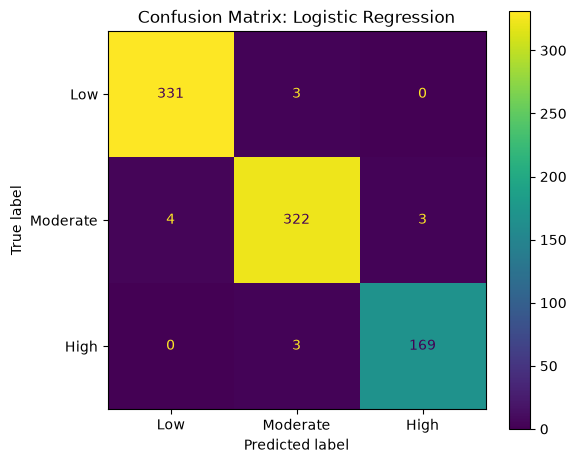

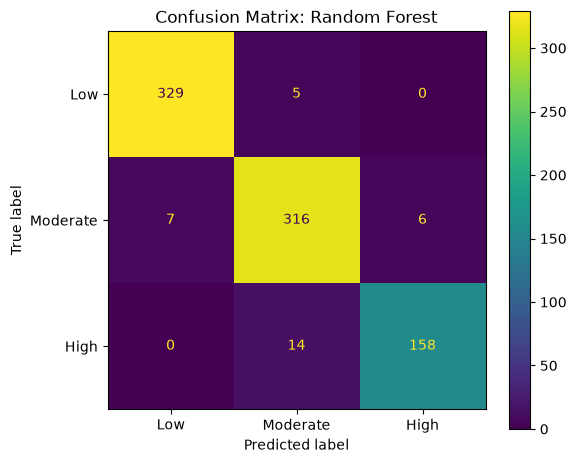

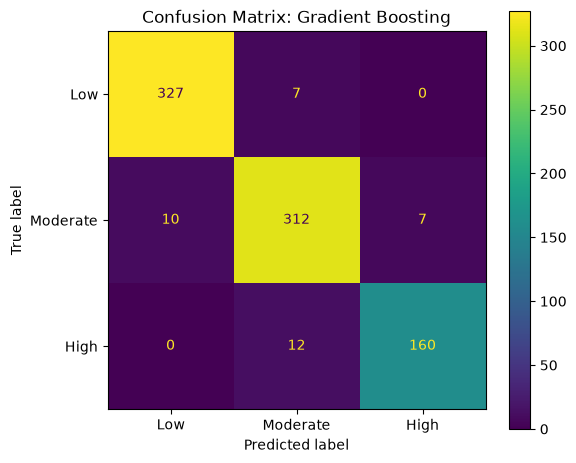

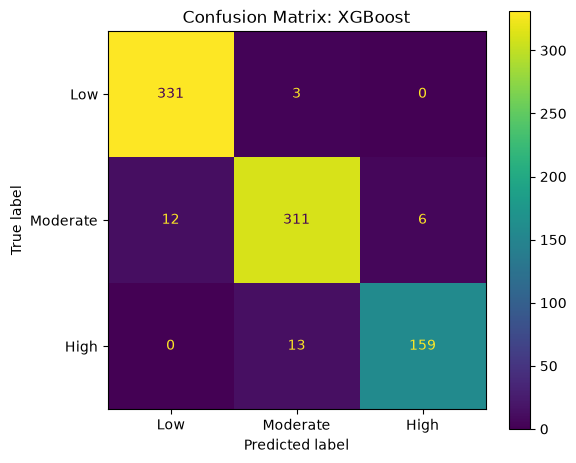

In [47]:
# ============================================================
# 15. DISPLAY CONFUSION MATRICES
# ============================================================
# A confusion matrix shows:
#
# - Correct class predictions along the diagonal
# - Incorrect class predictions outside the diagonal
#
# A separate figure is produced for every model.

for model_name, trained_model in trained_models.items():

    y_test_pred = trained_model.predict(
        X_test
    )

    confusion = confusion_matrix(
        y_test,
        y_test_pred,
        labels=CLASS_LABELS
    )

    display_object = ConfusionMatrixDisplay(
        confusion_matrix=confusion,
        display_labels=CLASS_NAMES
    )

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    display_object.plot(
        ax=ax,
        values_format="d"
    )

    ax.set_title(
        f"Confusion Matrix: {model_name}"
    )

    plt.tight_layout()
    plt.show()

,Model,Macro F1
0,Logistic Regression,0.9841
1,Random Forest,0.9581
2,XGBoost,0.9565
3,Gradient Boosting,0.9547


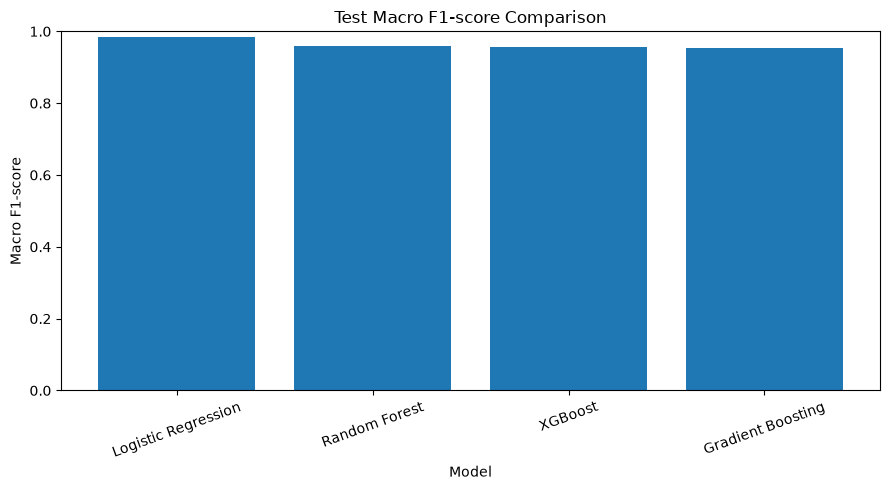

In [48]:
# ============================================================
# 16. COMPARE TEST MACRO F1-SCORES
# ============================================================
# Macro F1 gives equal importance to:
#
# - Low feasibility
# - Moderate feasibility
# - High feasibility
#
# Therefore, it is more suitable than accuracy when the target
# classes are not perfectly balanced.

macro_f1_comparison = (
    test_results_df[
        ["Model", "Macro F1"]
    ]
    .sort_values(
        by="Macro F1",
        ascending=False
    )
)

display(
    macro_f1_comparison.round(4)
)

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    macro_f1_comparison["Model"],
    macro_f1_comparison["Macro F1"]
)

plt.title(
    "Test Macro F1-score Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Macro F1-score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.tight_layout()
plt.show()

In [49]:
# ============================================================
# 17. DEFINE FIVE-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================
# StratifiedKFold creates five different train-validation
# combinations.
#
# Each fold maintains approximately the same target class
# proportions.
#
# shuffle=True randomizes the observations before constructing
# the folds.

stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

stratified_cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [50]:
# ============================================================
# 18. DEFINE CROSS-VALIDATION METRICS
# ============================================================
# Custom scorers are used so that zero_division=0 prevents
# warnings when a model does not predict one of the classes.

macro_precision_scorer = make_scorer(
    precision_score,
    average="macro",
    zero_division=0
)

macro_recall_scorer = make_scorer(
    recall_score,
    average="macro",
    zero_division=0
)

macro_f1_scorer = make_scorer(
    f1_score,
    average="macro",
    zero_division=0
)

cross_validation_scoring = {
    "accuracy": "accuracy",
    "macro_precision": macro_precision_scorer,
    "macro_recall": macro_recall_scorer,
    "macro_f1": macro_f1_scorer
}

In [51]:
# ============================================================
# 19. PERFORM FIVE-FOLD CROSS-VALIDATION
# ============================================================
# Cross-validation is performed using the complete pipeline.
#
# Therefore, the preprocessor is fitted separately inside
# every training fold.
#
# This prevents validation-fold information from leaking into
# training.

cross_validation_results = []

for model_name, model_pipeline in models.items():

    print("=" * 60)
    print(
        f"Running five-fold cross-validation: {model_name}"
    )

    cv_result = cross_validate(
        estimator=model_pipeline,
        X=X_train,
        y=y_train,
        cv=stratified_cv,
        scoring=cross_validation_scoring,
        return_train_score=False,
        n_jobs=-1
    )

    result_row = {
        "Model": model_name,

        "CV Accuracy Mean": np.mean(
            cv_result["test_accuracy"]
        ),

        "CV Accuracy Std": np.std(
            cv_result["test_accuracy"]
        ),

        "CV Macro Precision Mean": np.mean(
            cv_result["test_macro_precision"]
        ),

        "CV Macro Recall Mean": np.mean(
            cv_result["test_macro_recall"]
        ),

        "CV Macro F1 Mean": np.mean(
            cv_result["test_macro_f1"]
        ),

        "CV Macro F1 Std": np.std(
            cv_result["test_macro_f1"]
        )
    }

    cross_validation_results.append(
        result_row
    )

    print(
        f"Mean Macro F1: "
        f"{result_row['CV Macro F1 Mean']:.4f}"
    )

Running five-fold cross-validation: Logistic Regression
Mean Macro F1: 0.9832
Running five-fold cross-validation: Random Forest
Mean Macro F1: 0.9611
Running five-fold cross-validation: Gradient Boosting
Mean Macro F1: 0.9601
Running five-fold cross-validation: XGBoost
Mean Macro F1: 0.9678


In [52]:
# ============================================================
# 20. DISPLAY CROSS-VALIDATION RESULTS
# ============================================================

cross_validation_results_df = pd.DataFrame(
    cross_validation_results
)

cross_validation_results_df = (
    cross_validation_results_df
    .sort_values(
        by="CV Macro F1 Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    cross_validation_results_df.round(4)
)

,Model,CV Accuracy Mean,CV Accuracy Std,CV Macro Precision Mean,CV Macro Recall Mean,CV Macro F1 Mean,CV Macro F1 Std
0,Logistic Regression,0.9826,0.0020,0.9814,0.9851,0.9832,0.0027
1,XGBoost,0.9682,0.0078,0.9688,0.9672,0.9678,0.0084
2,Random Forest,0.9613,0.0083,0.9605,0.9621,0.9611,0.0087
3,Gradient Boosting,0.9607,0.0069,0.9617,0.9592,0.9601,0.0087


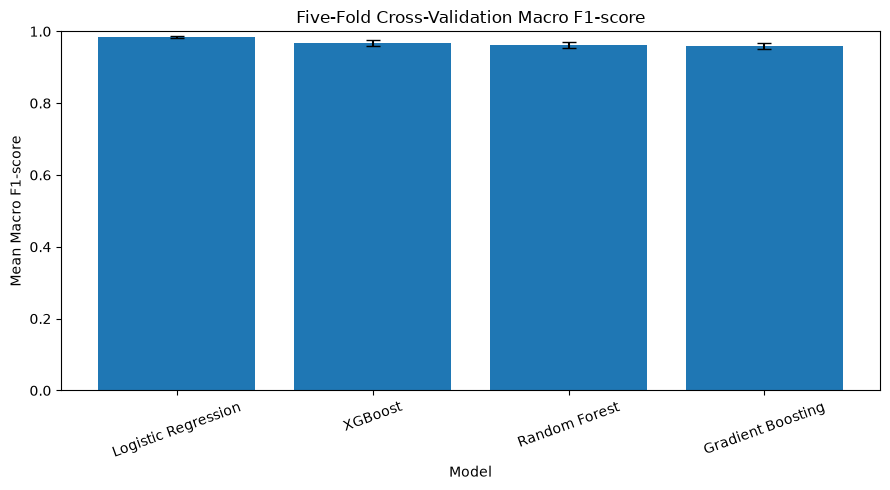

In [53]:
# ============================================================
# 21. PLOT CROSS-VALIDATION MACRO F1-SCORES
# ============================================================
# Error bars show the standard deviation across the five folds.
#
# A smaller standard deviation generally indicates more stable
# performance across different subsets of the data.

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    cross_validation_results_df["Model"],
    cross_validation_results_df["CV Macro F1 Mean"],
    yerr=cross_validation_results_df["CV Macro F1 Std"],
    capsize=5
)

plt.title(
    "Five-Fold Cross-Validation Macro F1-score"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Mean Macro F1-score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.tight_layout()
plt.show()

In [54]:
# ============================================================
# 22. PREPARE AREA-BASED VALIDATION
# ============================================================
# Area-based validation measures whether a model trained using
# some search areas can generalize to a completely different
# search area.
#
# GroupKFold ensures that observations from the same area do
# not appear in both the training and validation subsets.
#
# search_area is used as the grouping variable.

if "search_area" not in X_train.columns:
    raise ValueError(
        "search_area is required for area-based validation."
    )

area_groups = (
    X_train["search_area"]
    .astype("string")
    .fillna("Unknown")
)

number_of_areas = area_groups.nunique()

print(
    "Number of unique training areas:",
    number_of_areas
)

print("\nTraining observations by area:")

display(
    area_groups
    .value_counts()
    .to_frame("observation_count")
)

Number of unique training areas: 9

Training observations by area:


,observation_count
search_area,
Baneshwor,437
Patan durbar square,429
Bhaktapur durbar square,415
Boudha stupa,412
New Road,404
Koteshwor,327
Kirtipur,324
Durbar Marg,316
Pulchowk,273


In [55]:
# ============================================================
# 23. CREATE THE AREA-BASED GROUP KFOLD
# ============================================================
# A maximum of five folds is used.
#
# When fewer than five areas are available, the number of
# folds is reduced to the number of available areas.

area_cv_splits = min(
    5,
    number_of_areas
)

if area_cv_splits < 2:
    raise ValueError(
        "At least two different search areas are required "
        "for area-based validation."
    )

area_group_cv = GroupKFold(
    n_splits=area_cv_splits
)

print(
    "Number of area-based validation folds:",
    area_cv_splits
)

Number of area-based validation folds: 5


In [56]:
# ============================================================
# 24. PERFORM AREA-BASED VALIDATION
# ============================================================
# In each fold:
#
# - One or more complete areas are used for validation
# - The remaining areas are used for model training
#
# This is a harder test than normal random cross-validation
# because the validation area is geographically unseen.

area_validation_results = []

for model_name, model_pipeline in models.items():

    print("=" * 60)
    print(
        f"Running area-based validation: {model_name}"
    )

    area_result = cross_validate(
        estimator=model_pipeline,
        X=X_train,
        y=y_train,
        groups=area_groups,
        cv=area_group_cv,
        scoring=cross_validation_scoring,
        return_train_score=False,
        n_jobs=-1
    )

    result_row = {
        "Model": model_name,

        "Area Accuracy Mean": np.mean(
            area_result["test_accuracy"]
        ),

        "Area Accuracy Std": np.std(
            area_result["test_accuracy"]
        ),

        "Area Macro Precision Mean": np.mean(
            area_result["test_macro_precision"]
        ),

        "Area Macro Recall Mean": np.mean(
            area_result["test_macro_recall"]
        ),

        "Area Macro F1 Mean": np.mean(
            area_result["test_macro_f1"]
        ),

        "Area Macro F1 Std": np.std(
            area_result["test_macro_f1"]
        )
    }

    area_validation_results.append(
        result_row
    )

    print(
        f"Mean area Macro F1: "
        f"{result_row['Area Macro F1 Mean']:.4f}"
    )

Running area-based validation: Logistic Regression
Mean area Macro F1: 0.9753
Running area-based validation: Random Forest
Mean area Macro F1: 0.9145
Running area-based validation: Gradient Boosting
Mean area Macro F1: 0.9023
Running area-based validation: XGBoost
Mean area Macro F1: 0.9276


In [57]:
# ============================================================
# 25. DISPLAY AREA-BASED VALIDATION RESULTS
# ============================================================

area_validation_results_df = pd.DataFrame(
    area_validation_results
)

area_validation_results_df = (
    area_validation_results_df
    .sort_values(
        by="Area Macro F1 Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    area_validation_results_df.round(4)
)

,Model,Area Accuracy Mean,Area Accuracy Std,Area Macro Precision Mean,Area Macro Recall Mean,Area Macro F1 Mean,Area Macro F1 Std
0,Logistic Regression,0.9775,0.0082,0.9791,0.9721,0.9753,0.0086
1,XGBoost,0.9311,0.0302,0.9314,0.9278,0.9276,0.0278
2,Random Forest,0.9199,0.0311,0.9228,0.9134,0.9145,0.0275
3,Gradient Boosting,0.9069,0.0474,0.9069,0.9043,0.9023,0.0449


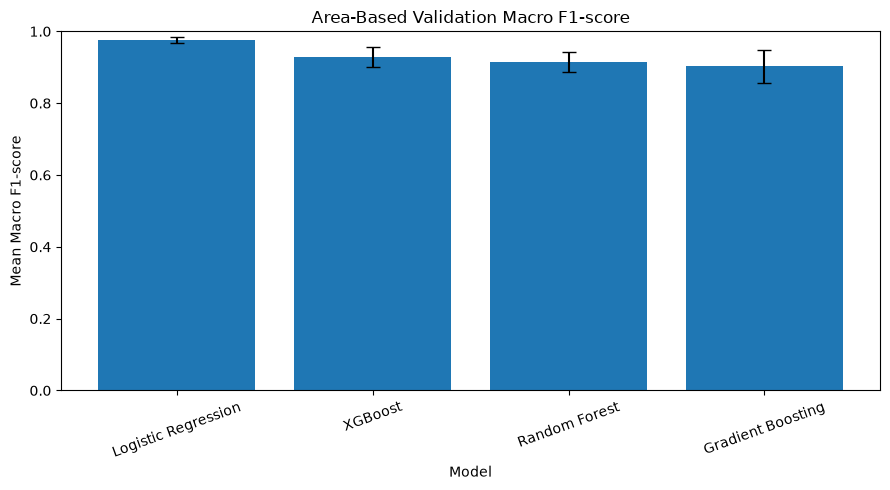

In [58]:
# ============================================================
# 26. PLOT AREA-BASED MACRO F1-SCORES
# ============================================================

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    area_validation_results_df["Model"],
    area_validation_results_df["Area Macro F1 Mean"],
    yerr=area_validation_results_df["Area Macro F1 Std"],
    capsize=5
)

plt.title(
    "Area-Based Validation Macro F1-score"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Mean Macro F1-score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=20
)

plt.tight_layout()
plt.show()

In [59]:
# ============================================================
# 27. COMBINE MODEL EVALUATION RESULTS
# ============================================================
# This table compares:
#
# - Test-set Macro F1
# - Five-fold CV Macro F1
# - Area-based Macro F1
#
# The test set provides final unseen-row performance.
#
# Five-fold CV provides general model stability.
#
# Area-based validation provides geographic generalization
# performance.

combined_results_df = (
    test_results_df[
        [
            "Model",
            "Accuracy",
            "Macro F1",
            "Log Loss"
        ]
    ]
    .merge(
        cross_validation_results_df[
            [
                "Model",
                "CV Macro F1 Mean",
                "CV Macro F1 Std"
            ]
        ],
        on="Model",
        how="left"
    )
    .merge(
        area_validation_results_df[
            [
                "Model",
                "Area Macro F1 Mean",
                "Area Macro F1 Std"
            ]
        ],
        on="Model",
        how="left"
    )
)

combined_results_df = (
    combined_results_df
    .sort_values(
        by="CV Macro F1 Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    combined_results_df.round(4)
)

,Model,Accuracy,Macro F1,Log Loss,CV Macro F1 Mean,CV Macro F1 Std,Area Macro F1 Mean,Area Macro F1 Std
0,Logistic Regression,0.9844,0.9841,0.0489,0.9832,0.0027,0.9753,0.0086
1,XGBoost,0.9593,0.9565,0.0912,0.9678,0.0084,0.9276,0.0278
2,Random Forest,0.9617,0.9581,0.1196,0.9611,0.0087,0.9145,0.0275
3,Gradient Boosting,0.9569,0.9547,0.1115,0.9601,0.0087,0.9023,0.0449


In [60]:
# ============================================================
# 28. SELECT THE BEST MODEL
# ============================================================
# The best model is selected using mean five-fold
# cross-validation Macro F1.
#
# The test-set score is not used as the primary model-selection
# criterion because repeatedly selecting models based on the
# test set could cause test-set overfitting.

best_model_name = (
    cross_validation_results_df
    .iloc[0]["Model"]
)

best_base_pipeline = models[
    best_model_name
]

best_cv_macro_f1 = (
    cross_validation_results_df
    .iloc[0]["CV Macro F1 Mean"]
)

print(
    "Best model before tuning:",
    best_model_name
)

print(
    "Mean five-fold CV Macro F1:",
    round(best_cv_macro_f1, 4)
)

Best model before tuning: Logistic Regression
Mean five-fold CV Macro F1: 0.9832


In [61]:
# ============================================================
# 29. DEFINE HYPERPARAMETER GRIDS
# ============================================================
# Each algorithm requires a different set of parameters.
#
# Parameters beginning with classifier__ refer to the
# classifier inside the Pipeline.
#
# GridSearchCV will test every parameter combination using
# five-fold stratified cross-validation.

parameter_grids = {
    "Logistic Regression": {
        "classifier__C": [
            0.01,
            0.1,
            1,
            10,
            100
        ],

        "classifier__solver": [
            "lbfgs",
            "newton-cg"
        ]
    },

    "Random Forest": {
        "classifier__n_estimators": [
            200,
            300,
            500
        ],

        "classifier__max_depth": [
            None,
            10,
            20
        ],

        "classifier__min_samples_split": [
            2,
            5,
            10
        ],

        "classifier__min_samples_leaf": [
            1,
            2,
            4
        ],

        "classifier__max_features": [
            "sqrt",
            "log2"
        ]
    },

    "Gradient Boosting": {
        "classifier__n_estimators": [
            100,
            200,
            300
        ],

        "classifier__learning_rate": [
            0.01,
            0.05,
            0.1
        ],

        "classifier__max_depth": [
            2,
            3,
            4
        ],

        "classifier__min_samples_split": [
            2,
            5
        ],

        "classifier__subsample": [
            0.8,
            1.0
        ]
    }
}

if XGBOOST_AVAILABLE:

    parameter_grids["XGBoost"] = {
        "classifier__n_estimators": [
            150,
            250,
            350
        ],

        "classifier__learning_rate": [
            0.01,
            0.05,
            0.1
        ],

        "classifier__max_depth": [
            3,
            4,
            6
        ],

        "classifier__subsample": [
            0.8,
            1.0
        ],

        "classifier__colsample_bytree": [
            0.8,
            1.0
        ]
    }

print(
    f"Hyperparameter grid prepared for: "
    f"{best_model_name}"
)

Hyperparameter grid prepared for: Logistic Regression


In [62]:
# ============================================================
# 30. TUNE THE BEST-PERFORMING MODEL
# ============================================================
# GridSearchCV:
#
# - Tries different hyperparameter combinations
# - Evaluates each combination using five-fold CV
# - Selects the combination with the highest Macro F1
#
# refit=True:
# After finding the best combination, the model is retrained
# using the complete training dataset.

best_model_parameter_grid = parameter_grids[
    best_model_name
]

grid_search = GridSearchCV(
    estimator=best_base_pipeline,
    param_grid=best_model_parameter_grid,
    scoring=macro_f1_scorer,
    cv=stratified_cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(
    X_train,
    y_train
)

print("Hyperparameter tuning completed.")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Hyperparameter tuning completed.


In [63]:
# ============================================================
# 31. DISPLAY THE BEST HYPERPARAMETERS
# ============================================================

print(
    "Tuned model:",
    best_model_name
)

print(
    "\nBest cross-validation Macro F1:",
    round(grid_search.best_score_, 4)
)

print("\nBest hyperparameters:")

for parameter_name, parameter_value in (
    grid_search.best_params_.items()
):
    print(
        f"{parameter_name}: {parameter_value}"
    )

Tuned model: Logistic Regression

Best cross-validation Macro F1: 0.993

Best hyperparameters:
classifier__C: 100
classifier__solver: lbfgs


In [65]:
# ============================================================
# 32. STORE THE TUNED MODEL
# ============================================================
# best_estimator_ contains the complete fitted pipeline:
#
# - Missing-value imputation
# - Numerical normalization
# - One-hot encoding
# - Tuned classifier

tuned_best_model = (
    grid_search.best_estimator_
)

print(
    "The complete tuned model pipeline is ready."
)

The complete tuned model pipeline is ready.


In [66]:
# ============================================================
# 33. EVALUATE THE TUNED MODEL ON THE TEST SET
# ============================================================
# The untouched test set is used to evaluate the final tuned
# model.
#
# This provides a more trustworthy estimate of its final
# predictive performance.

tuned_test_result = evaluate_model(
    model_name=f"Tuned {best_model_name}",
    model_pipeline=tuned_best_model,
    X_data=X_test,
    y_true=y_test
)

tuned_test_results_df = pd.DataFrame(
    [tuned_test_result]
)

display(
    tuned_test_results_df.round(4)
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Log Loss,Training Time
0,Tuned Logistic Regression,0.9952,0.995,0.995,0.995,0.9952,0.0152,NaN


In [67]:
# ============================================================
# 34. DISPLAY THE TUNED MODEL CLASSIFICATION REPORT
# ============================================================

tuned_y_pred = tuned_best_model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        tuned_y_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Low       1.00      1.00      1.00       334
    Moderate       0.99      0.99      0.99       329
        High       0.99      0.99      0.99       172

    accuracy                           1.00       835
   macro avg       1.00      1.00      1.00       835
weighted avg       1.00      1.00      1.00       835



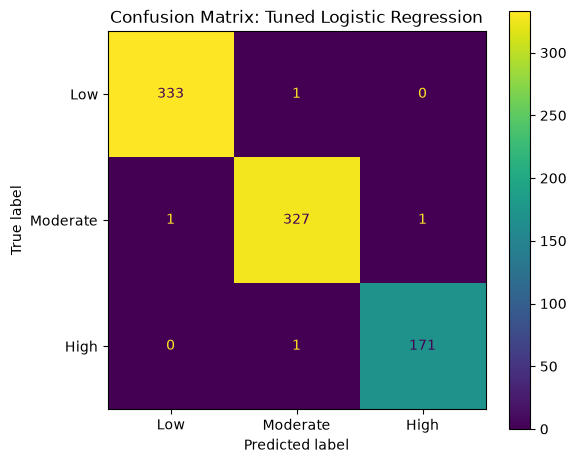

In [69]:
# ============================================================
# 35. DISPLAY THE TUNED MODEL CONFUSION MATRIX
# ============================================================

tuned_confusion_matrix = confusion_matrix(
    y_test,
    tuned_y_pred,
    labels=CLASS_LABELS
)

tuned_confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=tuned_confusion_matrix,
    display_labels=CLASS_NAMES
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

tuned_confusion_display.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    f"Confusion Matrix: Tuned {best_model_name}"
)

plt.tight_layout()
plt.show()

In [70]:
# ============================================================
# 36. COMPARE THE BASE AND TUNED MODEL
# ============================================================
# This comparison determines whether hyperparameter tuning
# improved the model's test performance.

base_model_result = (
    test_results_df[
        test_results_df["Model"] == best_model_name
    ]
    .copy()
)

base_model_result["Version"] = "Before tuning"

tuned_model_result = (
    tuned_test_results_df.copy()
)

tuned_model_result["Version"] = "After tuning"

base_tuned_comparison = pd.concat(
    [
        base_model_result[
            [
                "Version",
                "Accuracy",
                "Macro Precision",
                "Macro Recall",
                "Macro F1",
                "Weighted F1",
                "Log Loss"
            ]
        ],

        tuned_model_result[
            [
                "Version",
                "Accuracy",
                "Macro Precision",
                "Macro Recall",
                "Macro F1",
                "Weighted F1",
                "Log Loss"
            ]
        ]
    ],
    ignore_index=True
)

display(
    base_tuned_comparison.round(4)
)

,Version,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Log Loss
0,Before tuning,0.9844,0.9841,0.9841,0.9841,0.9844,0.0489
1,After tuning,0.9952,0.9950,0.9950,0.9950,0.9952,0.0152


In [71]:
# ============================================================
# 37. EXAMINE GRID SEARCH RESULTS
# ============================================================
# This table displays the best hyperparameter combinations
# evaluated during tuning.

grid_search_results_df = pd.DataFrame(
    grid_search.cv_results_
)

grid_search_summary = (
    grid_search_results_df[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "params"
        ]
    ]
    .sort_values(
        by="rank_test_score"
    )
    .head(10)
)

display(
    grid_search_summary
)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
8,1,0.993018,0.004063,0.999190,"{'classifier__C': 100, 'classifier__solver': '..."
9,2,0.992146,0.003844,0.998791,"{'classifier__C': 100, 'classifier__solver': '..."
6,3,0.989420,0.004486,0.996883,"{'classifier__C': 10, 'classifier__solver': 'l..."
7,4,0.988549,0.004255,0.996317,"{'classifier__C': 10, 'classifier__solver': 'n..."
4,5,0.983181,0.002712,0.990015,"{'classifier__C': 1, 'classifier__solver': 'lb..."
5,5,0.983181,0.002712,0.990324,"{'classifier__C': 1, 'classifier__solver': 'ne..."
2,7,0.974707,0.002009,0.978531,"{'classifier__C': 0.1, 'classifier__solver': '..."
3,7,0.974707,0.002009,0.978686,"{'classifier__C': 0.1, 'classifier__solver': '..."
1,9,0.953858,0.008316,0.958872,"{'classifier__C': 0.01, 'classifier__solver': ..."
0,9,0.953858,0.008316,0.958809,"{'classifier__C': 0.01, 'classifier__solver': ..."


In [72]:
# ============================================================
# 38. FINAL PHASE 4 SUMMARY
# ============================================================

print("=" * 60)
print("PHASE 4 COMPLETED SUCCESSFULLY")
print("=" * 60)

print(
    "\nModels evaluated:",
    list(models.keys())
)

print(
    "\nBest model before tuning:",
    best_model_name
)

print(
    "Best untuned CV Macro F1:",
    round(best_cv_macro_f1, 4)
)

print(
    "Best tuned CV Macro F1:",
    round(grid_search.best_score_, 4)
)

print(
    "Tuned test Macro F1:",
    round(
        tuned_test_result["Macro F1"],
        4
    )
)

print(
    "\nThe final tuned pipeline is stored in:"
)

print(
    "tuned_best_model"
)

PHASE 4 COMPLETED SUCCESSFULLY

Models evaluated: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']

Best model before tuning: Logistic Regression
Best untuned CV Macro F1: 0.9832
Best tuned CV Macro F1: 0.993
Tuned test Macro F1: 0.995

The final tuned pipeline is stored in:
tuned_best_model


# ============================================================
# 39. OBJECTS READY FOR PHASE 5
# ============================================================
# The main objects available after Phase 4 are:
#
# trained_models
# test_results_df
# cross_validation_results_df
# area_validation_results_df
# combined_results_df
# best_model_name
# grid_search
# tuned_best_model
# tuned_test_result
#
# Phase 5 will use tuned_best_model to:
#
# 31. Analyze feature importance
# 32. Save the complete model pipeline
# 33. Collect features for a selected map location
# 34. Predict Low, Moderate or High
# 35. Return predicted probabilities
# 36. Integrate the model with FastAPI